# Beating DLinear with a Mamba forecaster

A well-known result in machine learning time series forecasting is that the linear model (DLinear) is notoriously hard to beat. Zeng et al. (2023) showed that a single linear layer per channel, with no nonlinearity and no interaction between variables, matched or outperformed many Transformer-based forecasting models that had been published up to that point. The implication was that those models had not made meaningful use of their attention mechanisms and were largely learning linear trends that a direct regression could capture just as well.

Transformer architectures face a structural difficulty in this setting. Self-attention is quadratic in sequence length, which makes long input windows expensive, and the DLinear result suggests the community had been overfitting architecture to benchmark noise rather than solving the underlying problem.

State space models (SSMs) offer a different starting point. Like RNNs and LSTMs, modern SSMs maintain a hidden state that evolves over time. The Mamba model family (Gu and Dao, 2023, 2024) takes this further by making the transition matrices input-dependent, so the model can learn what to remember and what to discard at each step.

The goal of this project is to build a Mamba-style SSM from scratch and train it to the point where it outperforms DLinear when trained on a 32 GB Mac M1 system. We work on ETTm2, one of the most widely used standard benchmarks. The hardest version of this task would be beating DLinear on ETTh1, the smallest benchmark dataset, but that dataset is so strongly dominated by linear trends that doing so requires advanced architectural choices such as channel mixing, which lie beyond the scope of this project. On ETTm2 the task is achievable even on a personal laptop, particularly at longer forecast horizons where nonlinear dynamics become relevant. This is the main objective of this project.

## Dataset

First, we load all relevant libraries and load the ETTm2 dataset using the `load_data` function, which also normalizes each channel to zero mean and unit variance using statistics computed over the full dataset.

In [1]:
import os
import sys
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
import utils

df = utils.load_data(normalize = True, overwrite = False)

ETTm2 has 7 channels that measure electricity transformer statistics recorded at 15-minute intervals. The dataset spans roughly 2 years, from July 2016 to July 2018, with 69,680 timestamps in total. We allocate roughly 4 months of data each to validation and test, with the remaining 14 months used for training. Below is the plot of ETTm2 in each of its channels, along with the train/validation/test split we will be using.

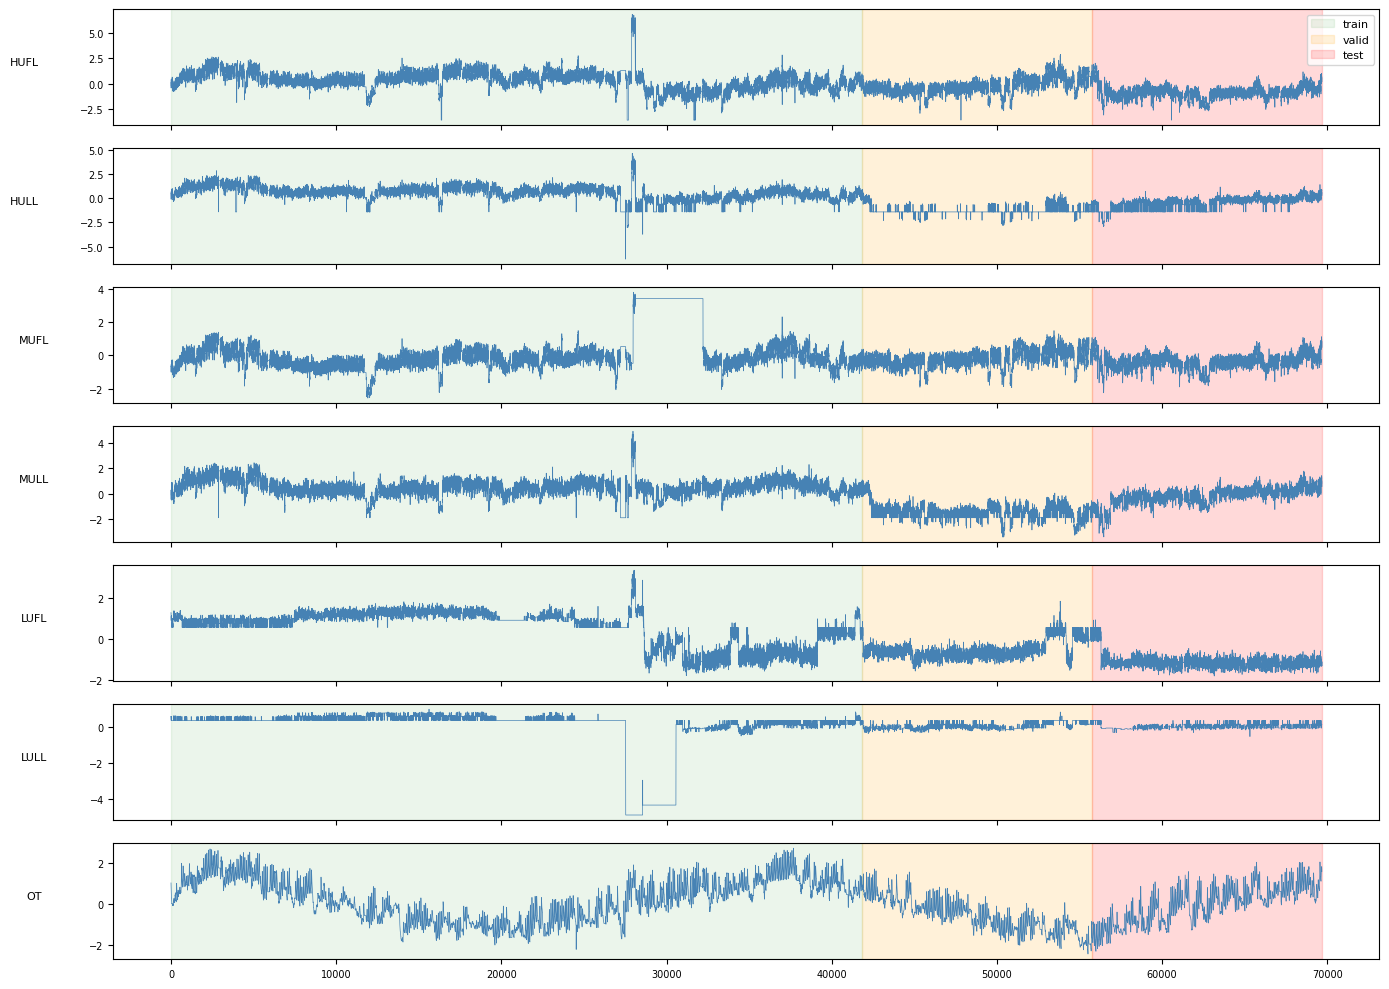

In [5]:
cols = df.select_dtypes(include = "number").columns
v_start = int(len(df) * 0.6)
t_start = int(len(df) * 0.8)

fig, axes = plt.subplots(len(cols), 1, figsize = (14, 10), sharex = True)
for ax, col in zip(axes, cols):
    ax.plot(df[col].values, linewidth = 0.5, color = "steelblue")
    ax.axvspan(0, v_start, alpha = 0.08, color = "green", label = "train")
    ax.axvspan(v_start, t_start, alpha = 0.15, color = "orange", label = "valid")
    ax.axvspan(t_start, len(df), alpha = 0.15, color = "red", label = "test")
    ax.set_ylabel(col, fontsize = 8, rotation = 0, labelpad = 40)
    ax.tick_params(labelsize = 7)

axes[0].legend(fontsize = 8, loc = "upper right")
fig.tight_layout()
plt.show()

The series as a whole is non-stationary, which is especially relevant at the longer horizons we will be working with. Because of this, we pair the Mamba model with RevIN (Kim et al., 2022), a reversible instance normalization layer. RevIN normalizes each input window to zero mean and unit variance at inference time, using statistics computed from that specific window rather than from the training set. The normalized input is then passed to the main model, and the output is denormalized using the same statistics before the loss is computed. This allows the model to focus on the shape of the signal rather than its absolute level and scale, which is particularly important for non-stationary series where the mean and variance shift over time.

## Architecture

DLinear is the simplest possible forecasting model: it applies an independent linear projection from `L` to `H` for each channel, with no cross-channel interaction and no nonlinearity of any kind. Despite this, it serves as a notoriously difficult baseline, as most architectures that introduce additional complexity fail to consistently outperform it.

We will attempt this task using a simple version of a modern SSM architecture designed for time series forecasting, implemented from scratch in `utils.py`. The model consists of a sequence of Mamba blocks through which the data is passed before reaching the forecasting heads. Similarly to classic LSTM-style models, each Mamba block splits the data flow into two streams: an SSM stream and a gate. The SSM stream passes through a depthwise convolution layer before entering the SSM, which introduces local mixing between nearby timesteps before the long-range recurrence takes over.

Schematically, this architecture is illustrated in the following figure.

![Model's architecture](../architecture.jpg)

This architecture is in many ways simple. All input channels are processed independently through the same shared sequence of Mamba blocks. In more advanced architectures, each channel has its own dedicated block pipeline, with cross-channel interactions introduced between blocks via attention or mixing layers.

Similarly to DLinear, the forecasting heads are independent per channel. Introducing cross-channel interactions at this stage carries an enormous parameter cost, and while it can be beneficial on large datasets, on ETTm2 it simply leads to overfitting.

The simplest SSM forecasting models predict based on the final hidden state that comes out of the last block. In such architectures, the forecasting head is a linear projection from `d_model` to `H`. There are two reasons to avoid this here. First, the final state vector can be noisy, as it is a single compressed summary of the entire input sequence. Second, since setting `d_model` to be comparable to `L` is not feasible due to runtime constraints, such an approach would create a severe information bottleneck that would undermine the capacity built up by the Mamba blocks. To address this, we introduce the parameter `n_tail`, which allows the forecasting head to operate on the final `n_tail` hidden states instead of just the last one. The input dimension of each forecasting head is then `d_model * n_tail`, which for reasonably small values of `n_tail` can be made comparable to `L` without a prohibitive parameter count.

Since ETTm2 is highly non-stationary, we pair the Mamba model with RevIN (Kim et al., 2022), a reversible instance normalization layer. RevIN normalizes each input window to zero mean and unit variance using statistics computed from that specific window, passes the normalized input to the model, and then reverses the normalization on the output before computing the loss. This allows the Mamba model to focus on the shape and dynamics of the signal rather than its absolute level and scale, which is critical when the mean and variance shift across the dataset.

## Training and Analysis

The relative performance of DLinear and the Mamba model depends strongly on the context length `L` and forecast horizon `H`. The standard forecasting literature considers the following values for these parameters: `{96, 192, 336, 512, 720}`. As mentioned in the introduction, beating DLinear at small `H` is difficult due to the dominance of linear trends. While possible, it generally requires advanced architectural choices and long training times. The Mamba model thrives when the forecast horizon is long relative to the context window, where nonlinear dynamics become relevant and linear extrapolation degrades.

In this project we illustrate the transition between these two regimes. We begin with `L, H = 336, 96`, where linear trends dominate and the Mamba model cannot beat DLinear. We then move to `L = H = 336`, where the two models are roughly tied, with Mamba ever so slightly ahead. Finally, we consider `L, H = 96, 336`, where the long horizon relative to the short context gives Mamba a clear advantage and it comfortably outperforms the linear baseline.

### L, H = 336, 96

In [4]:
L, H = 336, 96

train_loader, valid_loader, test_loader = utils.prepare_dataloaders(df, L, H, batch_size = 32, valid_len = 11520, test_len = 11520, step = 1)

#### DLinear

In [ ]:
DLinear = utils.DLinear(L = L, H = H, n_channels = 7)
DLinear = utils.train_model(
    DLinear,
    train_loader,
    valid_loader,
    epochs = 100,
    lr = 1e-4,
    revin = None,
    patience = 5,
    lr_patience = 3,
    weight_decay = 0.01,
    max_grad_norm = None,
    clip_start_batch = None,
    checkpoint = "best",
    model_dir = "../model/336-96/"
)

epoch 1: train_loss = 0.206867, valid_loss = 0.148245, grad_norm = 0.07969, lr = 1.00e-04
epoch 2: train_loss = 0.155283, valid_loss = 0.141907, grad_norm = 0.1504, lr = 1.00e-04
epoch 3: train_loss = 0.149375, valid_loss = 0.139389, grad_norm = 0.09627, lr = 1.00e-04
epoch 4: train_loss = 0.146546, valid_loss = 0.136227, grad_norm = 0.07559, lr = 1.00e-04
epoch 5: train_loss = 0.145052, valid_loss = 0.137558, grad_norm = 0.08788, lr = 1.00e-04
epoch 6: train_loss = 0.143993, valid_loss = 0.134790, grad_norm = 0.1208, lr = 1.00e-04
epoch 7: train_loss = 0.143279, valid_loss = 0.138469, grad_norm = 0.1389, lr = 1.00e-04
epoch 8: train_loss = 0.142696, valid_loss = 0.132732, grad_norm = 0.2083, lr = 1.00e-04
epoch 9: train_loss = 0.142166, valid_loss = 0.136753, grad_norm = 0.08731, lr = 1.00e-04
epoch 10: train_loss = 0.141866, valid_loss = 0.134325, grad_norm = 0.1596, lr = 1.00e-04
epoch 11: train_loss = 0.141542, valid_loss = 0.134001, grad_norm = 0.1088, lr = 1.00e-04
epoch 12: trai

The resulting model is saved in the `model/336-96/` directory and can be loaded using:

In [ ]:
DLinear = utils.load_model(f"../model/336-96/DLinear.pt")

Running it on the train, validation, and test datasets gives the following loss values:

In [19]:
print(f"Train MCE: {utils.evaluate(DLinear, train_loader, revin = None):.4f}")
print(f"Valid MCE: {utils.evaluate(DLinear, valid_loader, revin = None):.4f}")
print(f"Test MCE:  {utils.evaluate(DLinear, test_loader, revin = None):.4f}")

Train MCE: 0.1418
Valid MCE: 0.1327
Test MCE:  0.0957


#### Mamba

We initialize a Mamba model along with the corresponding RevIN layer.

In [3]:
mamba = utils.MambaModel(
    L, H,
    n_channels = 7,
    n_layers = 4,
    d_model = 48,
    d_inner = 64,
    d_state = 32,
    kernel_size = 64,
    n_tail = 32,
    dropout = 0.2
)
revin = utils.RevIN(n_channels = 7)

The model trained for seven epochs before the validation loss saturated, spread over several runs of:

In [ ]:
mamba, revin = utils.train_model(
    mamba,
    train_loader,
    valid_loader,
    epochs = 100,
    lr = 1e-5,
    revin = revin,
    patience = 3,
    lr_patience = 1,
    weight_decay = 0.05,
    max_grad_norm = None,
    clip_start_batch = None,
    checkpoint = "each",
    model_dir = "../model/336-96/"
)

The resulting model can be loaded with:

In [5]:
mamba = utils.load_model(f"../model/336-96/mamba.pt")
revin = utils.load_model(f"../model/336-96/revin.pt")

The corresponding losses on the train, validation, and test datasets are:

In [6]:
print(f"Train MCE: {utils.evaluate(mamba, train_loader, revin = revin):.4f}")
print(f"Valid MCE: {utils.evaluate(mamba, valid_loader, revin = revin):.4f}")
print(f"Test MCE:  {utils.evaluate(mamba, test_loader, revin = revin):.4f}")

Train MCE: 0.1448
Valid MCE: 0.1384
Test MCE:  0.0980


The model comes surprisingly close to the DLinear baseline, but surpassing it at `H = 96` would require architectural enhancements beyond the scope of this project.

### L, H = 336, 336

In this regime, our main objective is to match the linear baseline rather than beat it.

In [4]:
L, H = 336, 336

train_loader, valid_loader, test_loader = utils.prepare_dataloaders(df, L, H, batch_size = 32, valid_len = 11520, test_len = 11520, step = 1)

#### DLinear

In [ ]:
DLinear = utils.DLinear(L = L, H = H, n_channels = 7)
DLinear = utils.train_model(
    DLinear,
    train_loader,
    valid_loader,
    epochs = 100,
    lr = 1e-4,
    revin = None,
    patience = 5,
    lr_patience = 3,
    weight_decay = 0.01,
    max_grad_norm = None,
    clip_start_batch = None,
    checkpoint = "best",
    model_dir = "../model/336-336/"
)

epoch 1: train_loss = 0.312687, valid_loss = 0.233439, grad_norm = 0.1491, lr = 1.00e-04
epoch 2: train_loss = 0.272110, valid_loss = 0.231866, grad_norm = 0.121, lr = 1.00e-04
epoch 3: train_loss = 0.267486, valid_loss = 0.230734, grad_norm = 0.1122, lr = 1.00e-04
epoch 4: train_loss = 0.265445, valid_loss = 0.233146, grad_norm = 0.1007, lr = 1.00e-04
epoch 5: train_loss = 0.263873, valid_loss = 0.227102, grad_norm = 0.09621, lr = 1.00e-04
epoch 6: train_loss = 0.263050, valid_loss = 0.232875, grad_norm = 0.1443, lr = 1.00e-04
epoch 7: train_loss = 0.262329, valid_loss = 0.225712, grad_norm = 0.1555, lr = 1.00e-04
epoch 8: train_loss = 0.261900, valid_loss = 0.236177, grad_norm = 0.07807, lr = 1.00e-04
epoch 9: train_loss = 0.261402, valid_loss = 0.239929, grad_norm = 0.1347, lr = 1.00e-04
epoch 10: train_loss = 0.261023, valid_loss = 0.228693, grad_norm = 0.05517, lr = 1.00e-04
epoch 11: train_loss = 0.260691, valid_loss = 0.225810, grad_norm = 0.05067, lr = 5.00e-05
epoch 12: train_

It is saved in the `model/336-336/` directory and can be loaded with:

In [7]:
DLinear = utils.load_model(f"../model/336-336/DLinear.pt")

The respective MSE losses on the train, validation, and test sets are:

In [8]:
print(f"Train MCE: {utils.evaluate(DLinear, train_loader, revin = None):.4f}")
print(f"Valid MCE: {utils.evaluate(DLinear, valid_loader, revin = None):.4f}")
print(f"Test MCE:  {utils.evaluate(DLinear, test_loader, revin = None):.4f}")

Train MCE: 0.2617
Valid MCE: 0.2257
Test MCE:  0.1462


#### Mamba

We initialize a Mamba model with the following parameters. A RevIN layer is initialized alongside it.

In [ ]:
mamba = utils.MambaModel(
    L, H,
    n_channels = 7,
    n_layers = 4,
    d_model = 64,
    d_inner = 80,
    d_state = 32,
    kernel_size = 64,
    n_tail = 32,
    dropout = 0.2
)
revin = utils.RevIN(n_channels = 7)

The model was trained for three epochs before saturating, with learning rates across epochs adjusted manually.

In [ ]:
mamba, revin = utils.train_model(
    mamba,
    train_loader,
    valid_loader,
    epochs = 100,
    lr = 5e-5,
    revin = revin,
    patience = 3,
    lr_patience = 1,
    weight_decay = 0.05,
    max_grad_norm = None,
    clip_start_batch = None,
    checkpoint = "each",
    model_dir = "../model/336-336/"
)

The resulting Mamba and RevIN models can be loaded with:

In [5]:
mamba = utils.load_model(f"../model/336-336/mamba.pt")
revin = utils.load_model(f"../model/336-336/revin.pt")

The respective MSE losses on train, validation, and test sets are:

In [6]:
print(f"Train MCE: {utils.evaluate(mamba, train_loader, revin = revin):.4f}")
print(f"Valid MCE: {utils.evaluate(mamba, valid_loader, revin = revin):.4f}")
print(f"Test MCE:  {utils.evaluate(mamba, test_loader, revin = revin):.4f}")

Train MCE: 0.2229
Valid MCE: 0.2242
Test MCE:  0.1459


The Mamba model slightly outperforms DLinear across the board, though the difference is small enough to be within the margin of error. It is nonetheless impressive that the model reaches this level at all, given how difficult the DLinear benchmark is to beat. To open up a more significant gap at current values of `L` and `H`, the Mamba model would need dedicated per-channel block pipelines and cross-channel mixing layers between blocks, both of which lie beyond the intended scope of this project.

### L, H = 96, 336

A short context window paired with a long forecast horizon is the regime where Mamba has the strongest advantage over DLinear. We train a model that provides a meaningful improvement over the baseline.

In [4]:
L, H = 96, 336

train_loader, valid_loader, test_loader = utils.prepare_dataloaders(df, L, H, batch_size = 32, valid_len = 11520, test_len = 11520, step = 1)

#### DLinear

In [ ]:
DLinear = utils.DLinear(L = L, H = H, n_channels = 7)
DLinear = utils.train_model(
    DLinear,
    train_loader,
    valid_loader,
    epochs = 100,
    lr = 1e-4,
    revin = None,
    patience = 5,
    lr_patience = 3,
    weight_decay = 0.01,
    max_grad_norm = None,
    clip_start_batch = None,
    checkpoint = "best",
    model_dir = "../model/96-336/"
)

epoch 1: train_loss = 0.369794, valid_loss = 0.273956, grad_norm = 0.04164, lr = 1.00e-04
epoch 2: train_loss = 0.296349, valid_loss = 0.265917, grad_norm = 0.06421, lr = 1.00e-04
epoch 3: train_loss = 0.289779, valid_loss = 0.272112, grad_norm = 0.09315, lr = 1.00e-04
epoch 4: train_loss = 0.286799, valid_loss = 0.262393, grad_norm = 0.09025, lr = 1.00e-04
epoch 5: train_loss = 0.285064, valid_loss = 0.258485, grad_norm = 0.03125, lr = 1.00e-04
epoch 6: train_loss = 0.283918, valid_loss = 0.255534, grad_norm = 0.08725, lr = 1.00e-04
epoch 7: train_loss = 0.282968, valid_loss = 0.269889, grad_norm = 0.03937, lr = 1.00e-04
epoch 8: train_loss = 0.282550, valid_loss = 0.258832, grad_norm = 0.08023, lr = 1.00e-04
epoch 9: train_loss = 0.281990, valid_loss = 0.261830, grad_norm = 0.04126, lr = 1.00e-04
epoch 10: train_loss = 0.281567, valid_loss = 0.256927, grad_norm = 0.06105, lr = 5.00e-05
epoch 11: train_loss = 0.282914, valid_loss = 0.266306, grad_norm = 0.1132, lr = 5.00e-05
Early sto

The model can be loaded from the `model/96-336/` directory with:

In [2]:
DLinear = utils.load_model(f"../model/96-336/DLinear.pt")

The resulting train, validation, and test losses are:

In [5]:
print(f"Train MCE: {utils.evaluate(DLinear, train_loader, revin = None):.4f}")
print(f"Valid MCE: {utils.evaluate(DLinear, valid_loader, revin = None):.4f}")
print(f"Test MCE:  {utils.evaluate(DLinear, test_loader, revin = None):.4f}")

Train MCE: 0.2834
Valid MCE: 0.2555
Test MCE:  0.1646


#### Mamba

In [19]:
mamba = utils.MambaModel(
    L, H,
    n_channels = 7,
    n_layers = 4,
    d_model = 48,
    d_inner = 96,
    d_state = 48,
    kernel_size = 64,
    n_tail = 32,
    dropout = 0.2
)
revin = utils.RevIN(n_channels = 7)

Training ran for 13 epochs before the validation loss began to increase and early stopping was triggered.

In [20]:
mamba, revin = utils.train_model(
    mamba,
    train_loader,
    valid_loader,
    epochs = 100,
    lr = 1e-5,
    revin = revin,
    patience = 3,
    lr_patience = 1,
    weight_decay = 0.05,
    max_grad_norm = None,
    clip_start_batch = None,
    checkpoint = "each",
    model_dir = "../model/96-336/"
)

epoch 1: train_loss = 0.323732, valid_loss = 0.249462, grad_norm = 0.0524, lr = 1.00e-05
epoch 2: train_loss = 0.309283, valid_loss = 0.242678, grad_norm = 0.1072, lr = 1.00e-05
epoch 3: train_loss = 0.301327, valid_loss = 0.241257, grad_norm = 0.1404, lr = 1.00e-05
epoch 4: train_loss = 0.297032, valid_loss = 0.239626, grad_norm = 0.2896, lr = 1.00e-05
epoch 5: train_loss = 0.294576, valid_loss = 0.238875, grad_norm = 2.134, lr = 1.00e-05
epoch 6: train_loss = 0.292580, valid_loss = 0.237494, grad_norm = 0.2916, lr = 1.00e-05
epoch 7: train_loss = 0.291170, valid_loss = 0.236961, grad_norm = 0.4492, lr = 1.00e-05
epoch 8: train_loss = 0.289647, valid_loss = 0.238108, grad_norm = 0.1784, lr = 1.00e-05
epoch 9: train_loss = 0.288619, valid_loss = 0.236960, grad_norm = 0.1535, lr = 5.00e-06
epoch 10: train_loss = 0.289498, valid_loss = 0.239370, grad_norm = 0.1758, lr = 5.00e-06
epoch 11: train_loss = 0.288997, valid_loss = 0.238026, grad_norm = 0.8448, lr = 2.50e-06
epoch 12: train_loss

The resulting Mamba and RevIN models can be loaded with:

In [6]:
mamba = utils.load_model(f"../model/96-336/mamba.pt")
revin = utils.load_model(f"../model/96-336/revin.pt")

The  train, validation, and test losses are given by:

In [7]:
print(f"Train MCE: {utils.evaluate(mamba, train_loader, revin = revin):.4f}")
print(f"Valid MCE: {utils.evaluate(mamba, valid_loader, revin = revin):.4f}")
print(f"Test MCE:  {utils.evaluate(mamba, test_loader, revin = revin):.4f}")

Train MCE: 0.2876
Valid MCE: 0.2365
Test MCE:  0.1500


The Mamba model improves over the DLinear baseline by `8.87%` on the test set and `7.44%` on the validation set.

# Conclusions

We implemented a Mamba-style state space model from scratch and trained it on the ETTm2 benchmark across three context length and forecast horizon configurations. In the short-horizon regime, DLinear is almost impossible to beat. When the context length and horizon are comparable, the Mamba model marginally outperforms the linear baseline. The clearest advantage emerges in the short context, long horizon regime, where Mamba comfortably beats DLinear by a meaningful margin. This is a non-trivial result: DLinear is a notoriously difficult benchmark, and outperforming it with a relatively simple architecture trained on laptop-level hardware is an encouraging outcome.

Several lessons emerged from this project. First, the choice of forecast horizon matters greatly: at short horizons the signal is dominated by linear trends and DLinear is nearly impossible to beat, while at longer horizons nonlinear dynamics become relevant and sequence models have a genuine advantage. Second, overfitting is the central practical challenge on small datasets like ETTm2: controlling it requires careful tuning of dropout, weight decay, step size, and early stopping. Third, non-stationarity is a real concern for time series forecasting and instance normalization via RevIN is a simple and effective solution. Lastly, the shared-weight channel design adopted here is the main architectural limitation: dedicated per-channel pipelines with cross-channel mixing would likely close the remaining gap with more powerful baselines, at the cost of a larger and more complex model.